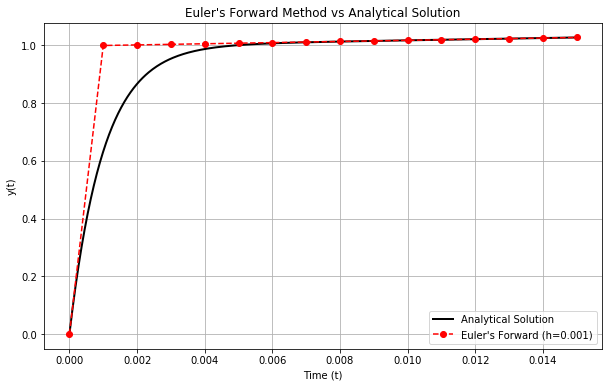

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# forward euler
def forward_euler(f, y0, t0, tf, h):
    t_values = np.arange(t0, tf+h, h)
    y_values = np.zeros_like(t_values)
    y_values[0] = y0
    
    for i in range(1, len(t_values)):
        y_values[i] = y_values[i-1] + h * f(t_values[i-1], y_values[i-1])
        
    return t_values, y_values

# Define the ODE: dy/dt = -1000y + 3000 - 2000*e^(-t)
def f(t, y):
    return -1000 * y + 3000 - 2000 * np.exp(-t)

# Define the Analytical Solution: y(t) = 3 - 0.998*e^(-1000t) - 2.002*e^(-t)
def analytical(t):
    return 3 - 0.998 * np.exp(-1000 * t) - 2.002 * np.exp(-t)

# Initial conditions and parameters
y0 = 0.0
t0 = 0.0
tf = 0.015 
h = 0.001   

# Solve using the numerical method
t_num, y_num = forward_euler(f, y0, t0, tf, h)

# points for the smooth analytical curve
t_exact = np.linspace(t0, tf, 500)
y_exact = analytical(t_exact)

# Plotting
plt.figure(figsize=(10, 6))

# analytical solution
plt.plot(t_exact, y_exact, label='Analytical Solution', color='black', linewidth=2)

# Euler's Forward method
plt.plot(t_num, y_num, label=f"Euler's Forward (h={h})", color='red', linestyle='--', marker='o')

plt.title("Euler's Forward Method vs Analytical Solution")
plt.xlabel("Time (t)")
plt.ylabel("y(t)")
plt.legend()
plt.grid(True)
plt.show()